# Week 10: K-Means Clustering and Silhouette Score

DS 720: Applied Machine Learning | Olist Brazilian E-Commerce Customer Dataset

Dataset: `olist_customers_dataset.csv` (real Olist Brazilian E-Commerce dataset, 99,441 customer records)

In [1]:
import pandas as pd, numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA
from sklearn.utils import resample

rng = 42
plt.rcParams.update({"font.size": 11})

df = pd.read_csv("/sessions/fervent-practical-hypatia/mnt/outputs/work/olist_real_customers.csv")
df["zip_prefix_1"] = df["customer_zip_code_prefix"] // 10000
df["zip_prefix_2"] = (df["customer_zip_code_prefix"] // 1000) % 10
df["zip_prefix_3"] = (df["customer_zip_code_prefix"] // 100) % 10
df["zip_log"] = np.log1p(df["customer_zip_code_prefix"])
city_counts = df["customer_city"].value_counts()
df["city_freq"] = df["customer_city"].map(city_counts)

le = LabelEncoder()
df["region_label"] = le.fit_transform(df["region"])
region_names = le.classes_

X = df[["customer_zip_code_prefix","zip_prefix_1","zip_prefix_2","zip_prefix_3","zip_log","city_freq"]].values
y = df["region_label"].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_sub, y_sub = resample(X_scaled, y, n_samples=6000, random_state=rng, stratify=y)

ks = list(range(2, 11))
inertias, sils, aris = [], [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=rng)
    labels = km.fit_predict(X_sub)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_sub, labels, sample_size=3000, random_state=rng)
    sils.append(sil)
    ari = adjusted_rand_score(y_sub, labels)
    aris.append(ari)
    print(f"k={k}  inertia={km.inertia_:,.0f}  silhouette={sil:.4f}  ARI_vs_region={ari:.4f}")

best_k_sil = ks[int(np.argmax(sils))]
print("Best k by silhouette:", best_k_sil, "silhouette:", max(sils))
print("k=5 (region count) silhouette:", sils[ks.index(5)], "ARI:", aris[ks.index(5)])

# final clustering at silhouette-optimal k and at k=5 for comparison
km_best = KMeans(n_clusters=best_k_sil, n_init=10, random_state=rng)
labels_best = km_best.fit_predict(X_sub)

km5 = KMeans(n_clusters=5, n_init=10, random_state=rng)
labels5 = km5.fit_predict(X_sub)

# crosstab of k=5 clusters vs true region
ct = pd.crosstab(pd.Series(labels5, name="cluster"), pd.Series(y_sub, name="region").map(dict(enumerate(region_names))))
print("\nCrosstab (k=5 clusters vs true region):")
print(ct)

# ---- Figure 1: elbow (inertia) + silhouette, 2-panel ----
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
axes[0].plot(ks, inertias, marker="o")
axes[0].set_xlabel("k (number of clusters)")
axes[0].set_ylabel("Inertia (within-cluster SSE)")
axes[0].set_title("K-Means Elbow Plot")

axes[1].plot(ks, sils, marker="s", color="darkorange")
axes[1].axvline(best_k_sil, color="gray", linestyle="--", alpha=0.7, label=f"best k={best_k_sil}")
axes[1].axvline(5, color="green", linestyle=":", alpha=0.7, label="k=5 (region count)")
axes[1].set_xlabel("k (number of clusters)")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette Score by k")
axes[1].legend()
plt.tight_layout()
plt.savefig("/sessions/fervent-practical-hypatia/mnt/outputs/figures/fig_wk10_elbow_silhouette.png", dpi=200)
plt.close()

# ---- Figure 2: PCA scatter of k=5 clusters vs true regions, 2-panel ----
pca = PCA(n_components=2, random_state=rng)
X_pca = pca.fit_transform(X_sub)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
sc0 = axes[0].scatter(X_pca[:,0], X_pca[:,1], c=y_sub, cmap="tab10", s=8, alpha=0.6)
axes[0].set_title("True Region Labels (PCA projection)")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
handles0, _ = sc0.legend_elements()
axes[0].legend(handles0, list(region_names), fontsize=8, loc="best")

sc1 = axes[1].scatter(X_pca[:,0], X_pca[:,1], c=labels5, cmap="tab10", s=8, alpha=0.6)
axes[1].set_title("K-Means Clusters (k=5, PCA projection)")
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")
handles1, _ = sc1.legend_elements()
axes[1].legend(handles1, [f"Cluster {i}" for i in range(5)], fontsize=8, loc="best")
plt.tight_layout()
plt.savefig("/sessions/fervent-practical-hypatia/mnt/outputs/figures/fig_wk10_pca_clusters.png", dpi=200)
plt.close()

print("\n--- SUMMARY FOR WRITEUP ---")
print("ks:", ks)
print("silhouettes:", [round(s,4) for s in sils])
print("aris:", [round(a,4) for a in aris])
print("best_k_sil:", best_k_sil, "sil:", round(max(sils),4))
print("k5 sil:", round(sils[ks.index(5)],4), "k5 ari:", round(aris[ks.index(5)],4))


k=2  inertia=22,107  silhouette=0.3297  ARI_vs_region=0.5847
k=3  inertia=15,121  silhouette=0.3861  ARI_vs_region=0.4957
k=4  inertia=12,240  silhouette=0.3500  ARI_vs_region=0.2423
k=5  inertia=10,578  silhouette=0.3466  ARI_vs_region=0.1674
k=6  inertia=9,103  silhouette=0.3331  ARI_vs_region=0.1904
k=7  inertia=8,081  silhouette=0.3351  ARI_vs_region=0.1471
k=8  inertia=7,225  silhouette=0.3430  ARI_vs_region=0.1624
k=9  inertia=6,437  silhouette=0.3619  ARI_vs_region=0.1361
k=10  inertia=6,019  silhouette=0.3599  ARI_vs_region=0.1209
Best k by silhouette: 3 silhouette: 0.3861289917590816
k=5 (region count) silhouette: 0.3466050091690368 ARI: 0.1673959366716377

Crosstab (k=5 clusters vs true region):
region   Central-West  North  Northeast  South  Southeast
cluster                                                  
0                   0      0         87      0       1026
1                   0      0        126      0        892
2                   0      0          0      0       

## Figures

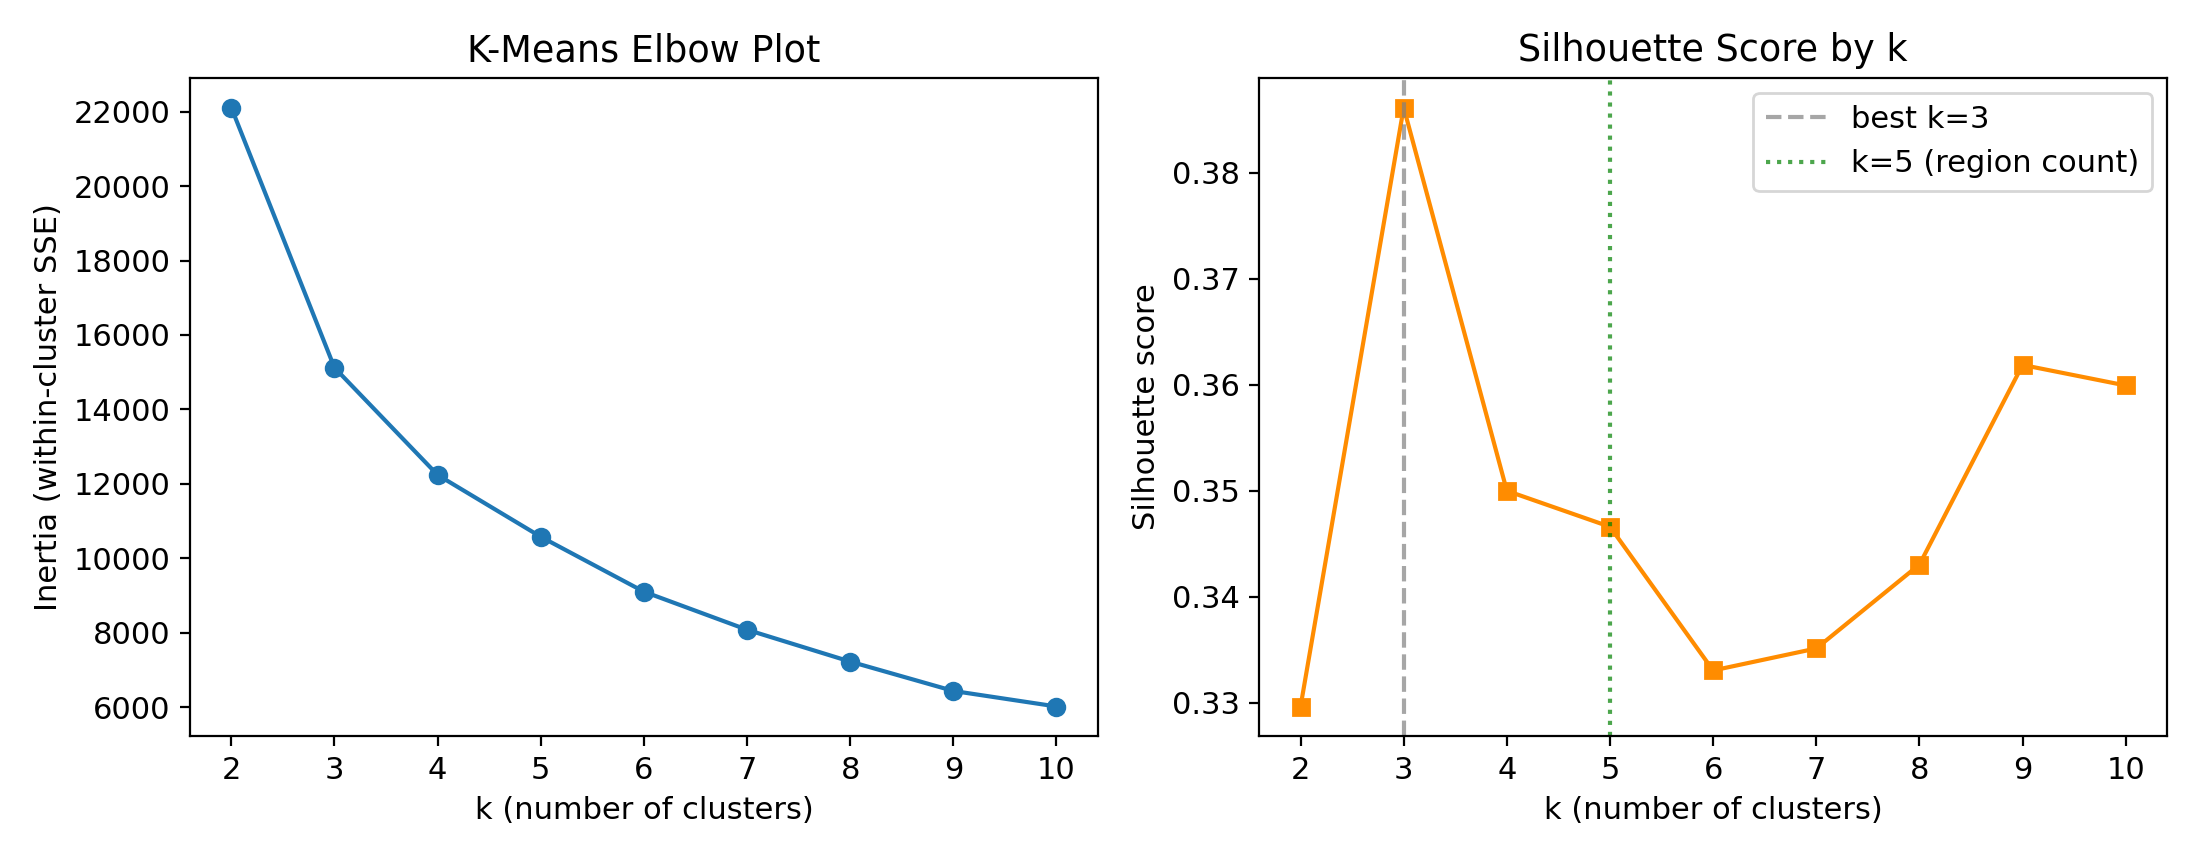

In [2]:
# Display Figure 1
from IPython.display import Image, display
display(Image(filename='fig_wk10_elbow_silhouette.png'))

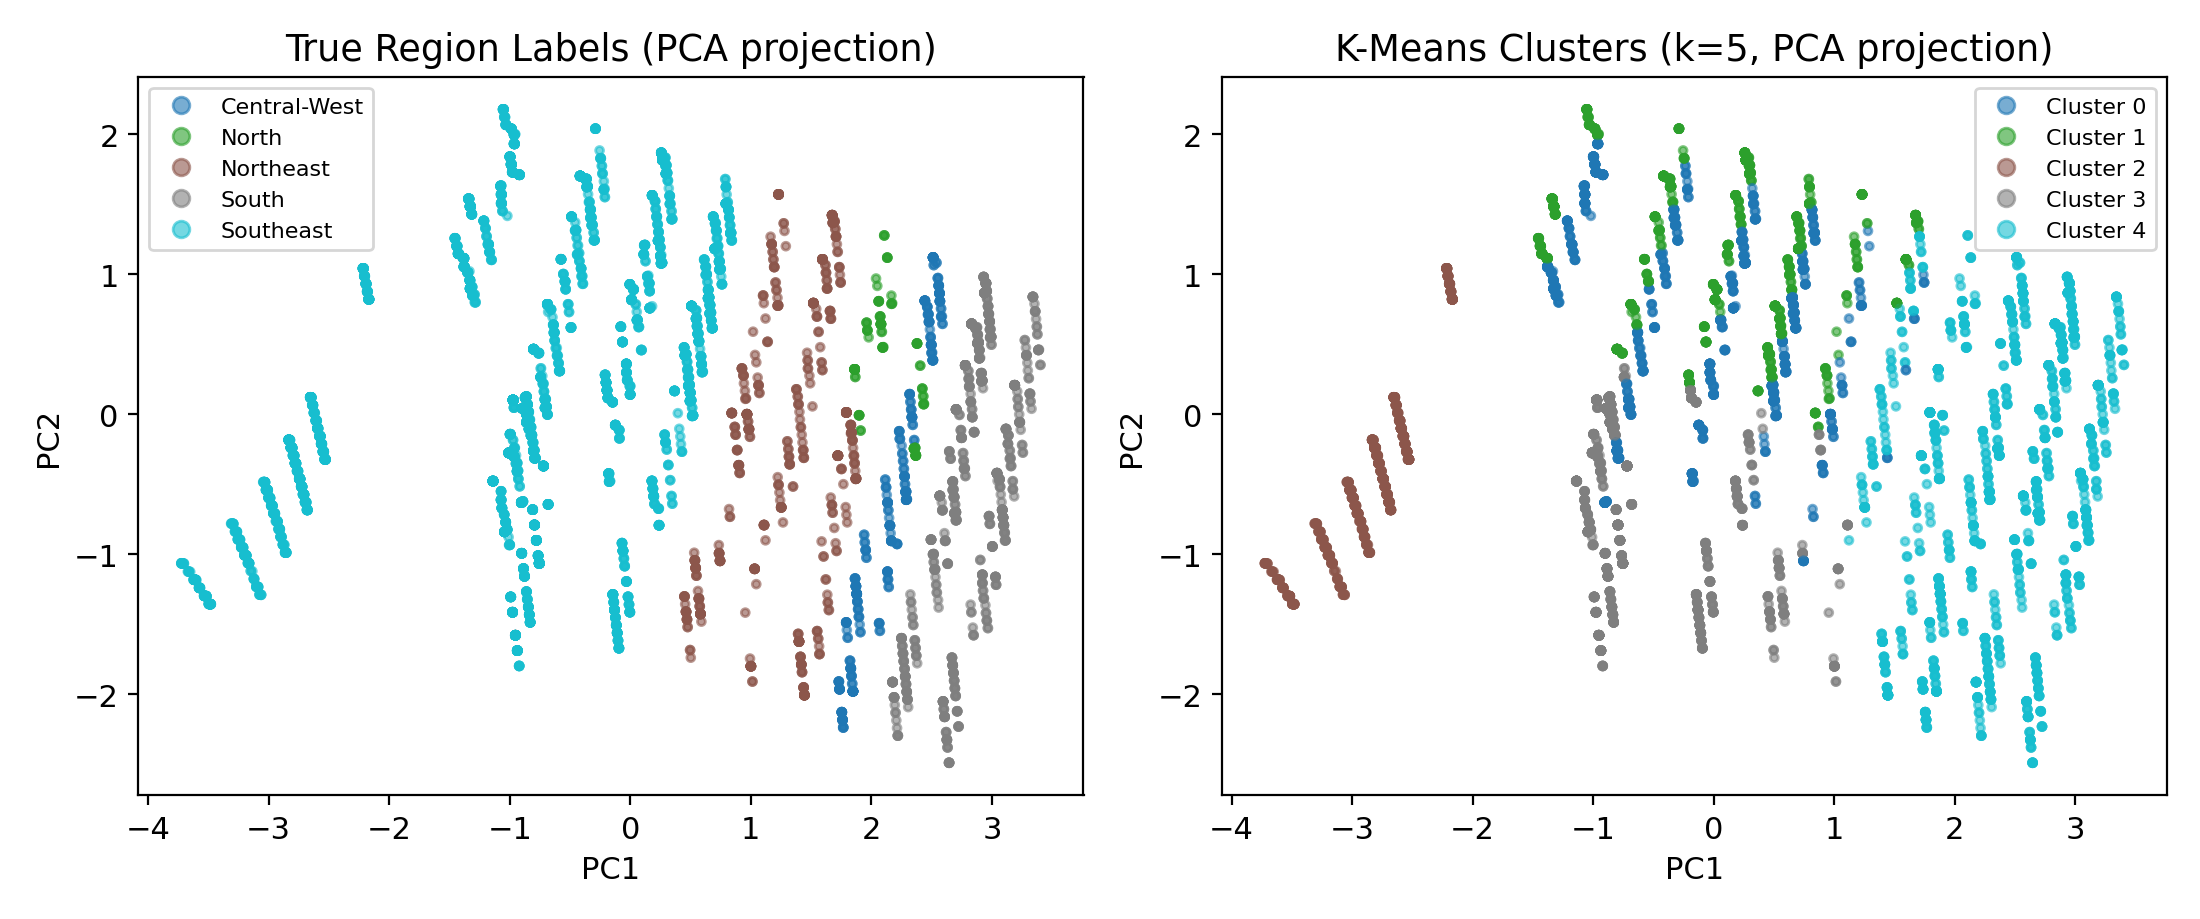

In [3]:
# Display Figure 2
from IPython.display import Image, display
display(Image(filename='fig_wk10_pca_clusters.png'))

**Conclusion:** Silhouette score peaked at k=3 (0.386), not at k=5 (the true region count, 0.347). See Milestone 2 summary document for full discussion.